<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>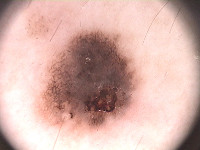</td><td>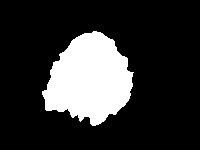</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [55]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=ac774ddc-dba2-498d-adf7-10ef2d407c6c
To: /kaggle/working/PH2Dataset.rar
100%|█████████████████████████████████████████| 162M/162M [00:01<00:00, 121MB/s]


In [56]:
get_ipython().system_raw("unrar x PH2Dataset.rar")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from PH2Dataset.rar

Program aborted




Would you like to replace the existing file PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image/IMD002.bmp
1313366 bytes, modified on 2020-07-03 15:00
with a new one
1313366 bytes, modified on 2020-07-03 15:00

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [57]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [58]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [59]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

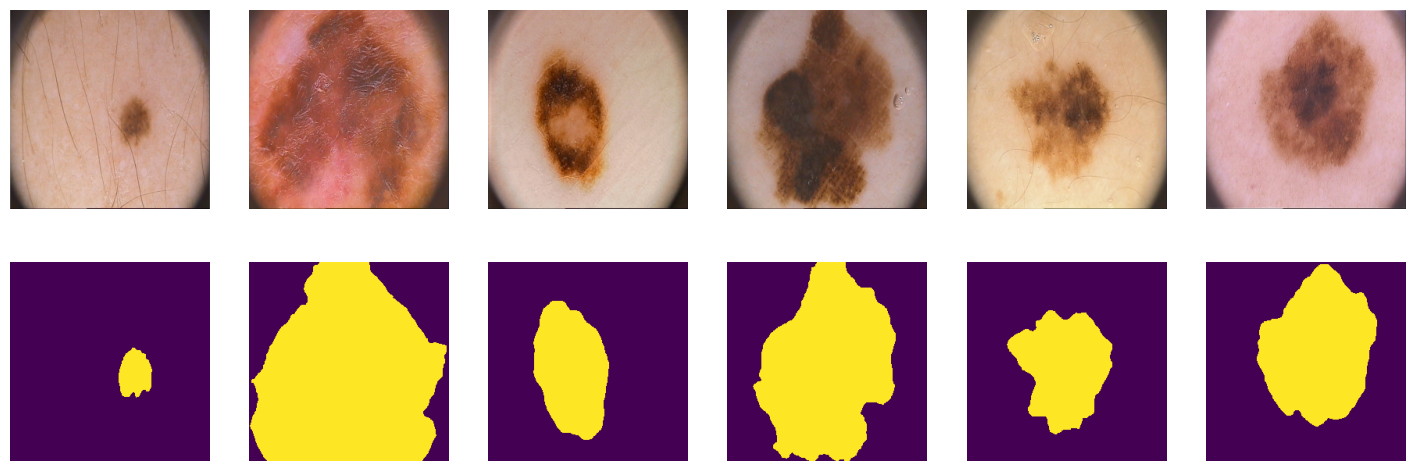

In [60]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [61]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [62]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [63]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [64]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [65]:
!pip install torchmetrics

In [66]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

Обозначим логит как $x = \hat y$. Тогда

$$\sigma(x)=\frac{1}{1+e^{-x}}, \quad 1-\sigma(x)=\frac{e^{-x}}{1+e^{-x}}.$$

Подставим это в BCE:

$$
\begin{aligned}
\mathcal L
&= -\left[y\log\sigma(x) + (1-y)\log(1-\sigma(x))\right] \\
&= -\left[y\log\frac{1}{1+e^{-x}} + (1-y)\log\frac{e^{-x}}{1+e^{-x}}\right] \\
&= y\log(1+e^{-x}) - (1-y)(-x-\log(1+e^{-x})) \\
&= (1-y)x + \log(1+e^{-x}) \\
&= x - yx + \log(1+e^{-x}).
\end{aligned}
$$



### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [67]:
import torch.nn.functional as F
import torch.nn as nn

In [68]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [69]:
def bce_loss(y_pred, y_real):
    y_real = y_real.to(dtype=y_pred.dtype)
    loss = torch.clamp(y_pred, min=0) - y_pred * y_real + torch.log1p(torch.exp(-torch.abs(y_pred)))
    return loss.sum()


def bce_true(y_pred, y_real):
    y_real = y_real.to(dtype=y_pred.dtype)
    eps = torch.finfo(y_pred.dtype).eps
    y_prob = torch.sigmoid(y_pred).clamp(min=eps, max=1 - eps)
    loss = -(y_real * torch.log(y_prob) + (1 - y_real) * torch.log(1 - y_prob))
    return loss.sum()


Проверим корректность работы на простом примере

In [70]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.4599761962890625
BCE loss честно посчитанный                = 4.4599761962890625
BCE loss from torch bce_torch              = 4.4599761962890625
BCE loss from torch with logits bce_torch  = 4.4599761962890625


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [71]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [72]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 12.329564094543457
BCE loss честно посчитанный               = 12.329564094543457
BCE loss from torch bce_torch             = 12.329564094543457
BCE loss from torch with logits bce_torch = 12.329564094543457


In [73]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [74]:
# Kaggle-only: скачиваем dummy logits/labels для assert-проверок.
import os
from pathlib import Path

get_ipython().system('pip -q install gdown')

path_to_dummy_samples = Path('/kaggle/working/for_asserts')
if not (path_to_dummy_samples / 'logits.pt').exists() or not (path_to_dummy_samples / 'labels.pt').exists():
    get_ipython().system('gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M -O /kaggle/working')

path_to_dummy_samples = str(path_to_dummy_samples)
print('Dummy samples path:', path_to_dummy_samples)


Dummy samples path: /kaggle/working/for_asserts


In [75]:
dummpy_sample = {
    'logits': torch.load(os.path.join(path_to_dummy_samples, 'logits.pt'), map_location=device),
    'labels': torch.load(os.path.join(path_to_dummy_samples, 'labels.pt'), map_location=device),
}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)


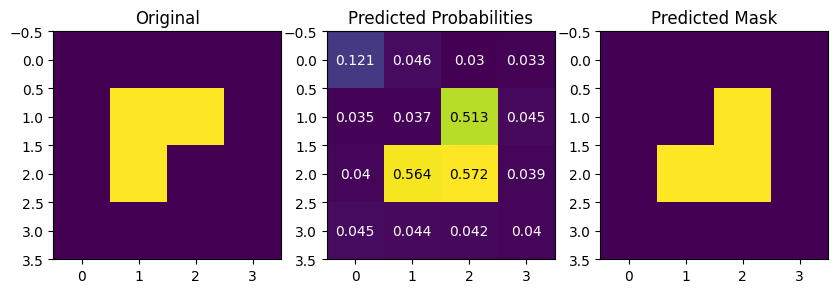

In [76]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [77]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

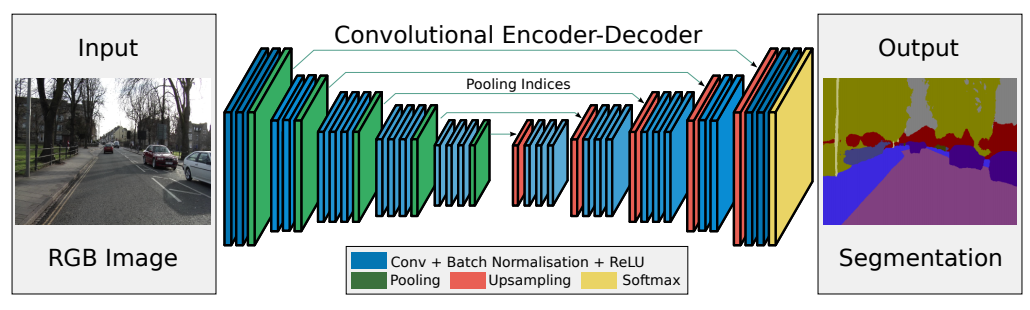

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [79]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [80]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [81]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [82]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, final=False):
        super(DecoderBlock, self).__init__()
        self.unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.layers = nn.ModuleList()

        for _ in range(depth - 1):
            self.layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding))
        if not final:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.unpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x


Соединим блоки энкодера и декодера в модель SegNet:

In [83]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, final=True)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)
        return output  # no activation


## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [84]:
from tqdm.notebook import tqdm

In [85]:
import random
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def _to_device(batch, device=device):
    images, masks = batch
    images = images.to(device=device, dtype=torch.float32)
    masks = masks.to(device=device, dtype=torch.float32)
    return images, masks


def _batch_iou(logits, masks, threshold=0.5, eps=1e-7):
    preds = torch.sigmoid(logits) > threshold
    targets = masks > 0.5
    intersection = (preds & targets).sum(dim=(1, 2, 3)).float()
    union = (preds | targets).sum(dim=(1, 2, 3)).float()
    return ((intersection + eps) / (union + eps)).mean().item()


@torch.no_grad()
def evaluate(model, dataloader, criterion, device=device):
    model.eval()
    total_loss, total_iou, total_objects = 0.0, 0.0, 0

    for batch in dataloader:
        images, masks = _to_device(batch, device)
        logits = model(images)
        loss = criterion(logits, masks)
        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_iou += _batch_iou(logits, masks) * batch_size
        total_objects += batch_size

    return {
        'loss': total_loss / total_objects,
        'iou': total_iou / total_objects,
    }


@torch.no_grad()
def show_predictions(model, batch, max_items=1, threshold=0.5, device=device, title=None):
    model.eval()
    images, masks = _to_device(batch, device)
    logits = model(images)
    probs = logits.sigmoid()
    preds = (probs > threshold).float()

    images = images.detach().cpu().permute(0, 2, 3, 1).numpy()
    masks = masks.detach().cpu().squeeze(1).numpy()
    probs = probs.detach().cpu().squeeze(1).numpy()
    preds = preds.detach().cpu().squeeze(1).numpy()

    n = min(max_items, len(images))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes[None, :]

    for i in range(n):
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title('Image')
        axes[i, 1].imshow(masks[i], cmap='gray')
        axes[i, 1].set_title('Mask')
        axes[i, 2].imshow(probs[i], cmap='magma', vmin=0, vmax=1)
        axes[i, 2].set_title('Probability')
        axes[i, 3].imshow(preds[i], cmap='gray')
        axes[i, 3].set_title('Prediction')
        for ax in axes[i]:
            ax.axis('off')

    if title is not None:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_history(history, title='Training'):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['valid_loss'], label='valid')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(history['train_iou'], label='train')
    axes[1].plot(history['valid_iou'], label='valid')
    axes[1].set_title('IoU')
    axes[1].set_xlabel('epoch')
    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_history_with_predictions(model, history, sample_batch, title='Training', device=device):
    plot_history(history, title=title)
    show_predictions(model, sample_batch, max_items=1, device=device, title='Validation prediction')


def compare_models(models_dict, dataloader=test_dataloader, max_items=1, threshold=0.5, device=device):
    batch = next(iter(dataloader))
    images, masks = _to_device(batch, device)
    images_np = images.detach().cpu().permute(0, 2, 3, 1).numpy()
    masks_np = masks.detach().cpu().squeeze(1).numpy()
    n = min(max_items, images.size(0))

    fig, axes = plt.subplots(n, 2 + len(models_dict), figsize=(4 * (2 + len(models_dict)), 3.5 * n))
    if n == 1:
        axes = axes[None, :]

    for i in range(n):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title('Image')
        axes[i, 1].imshow(masks_np[i], cmap='gray')
        axes[i, 1].set_title('Mask')
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')

    for col, (name, model) in enumerate(models_dict.items(), start=2):
        model.eval()
        with torch.no_grad():
            preds = (model(images).sigmoid() > threshold).float().cpu().squeeze(1).numpy()
        for i in range(n):
            axes[i, col].imshow(preds[i], cmap='gray')
            axes[i, col].set_title(name)
            axes[i, col].axis('off')

    plt.tight_layout()
    plt.show()


def summarize_histories(histories):
    rows = []
    for name, history in histories.items():
        rows.append({
            'run': name,
            'best_val_iou': max(history['valid_iou']),
            'final_val_iou': history['valid_iou'][-1],
            'best_val_loss': min(history['valid_loss']),
            'final_val_loss': history['valid_loss'][-1],
            'seconds': history['seconds'],
        })
    return pd.DataFrame(rows).sort_values('best_val_iou', ascending=False).reset_index(drop=True)


In [86]:
def train(model,
          train_dataloader=train_dataloader,
          valid_dataloader=valid_dataloader,
          criterion=None,
          optimizer=None,
          epochs=20,
          device=device,
          checkpoint_path='best_model.pt',
          title='Training',
          plot_every=1):
    if criterion is None:
        criterion = nn.BCEWithLogitsLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_iou': [],
        'valid_iou': [],
        'seconds': 0.0,
    }
    best_iou = -1.0
    best_state = None
    sample_batch = next(iter(valid_dataloader))
    start_time = time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_iou, total_objects = 0.0, 0.0, 0

        progress = tqdm(train_dataloader, desc=f'{title}: epoch {epoch}/{epochs}', leave=False)
        for batch in progress:
            images, masks = _to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            batch_iou = _batch_iou(logits.detach(), masks)
            total_loss += loss.item() * batch_size
            total_iou += batch_iou * batch_size
            total_objects += batch_size
            progress.set_postfix(loss=total_loss / total_objects, iou=total_iou / total_objects)

        train_metrics = {
            'loss': total_loss / total_objects,
            'iou': total_iou / total_objects,
        }
        valid_metrics = evaluate(model, valid_dataloader, criterion, device=device)

        history['train_loss'].append(train_metrics['loss'])
        history['train_iou'].append(train_metrics['iou'])
        history['valid_loss'].append(valid_metrics['loss'])
        history['valid_iou'].append(valid_metrics['iou'])
        history['seconds'] = time() - start_time

        if valid_metrics['iou'] > best_iou:
            best_iou = valid_metrics['iou']
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

        if epoch % plot_every == 0 or epoch == epochs:
            plot_history_with_predictions(
                model,
                history,
                sample_batch,
                title=f'{title} | best val IoU: {best_iou:.4f}',
                device=device,
            )
            print(
                f'Epoch {epoch:03d}/{epochs:03d} | '
                f'train loss {train_metrics["loss"]:.4f}, train IoU {train_metrics["iou"]:.4f} | '
                f'valid loss {valid_metrics["loss"]:.4f}, valid IoU {valid_metrics["iou"]:.4f}'
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

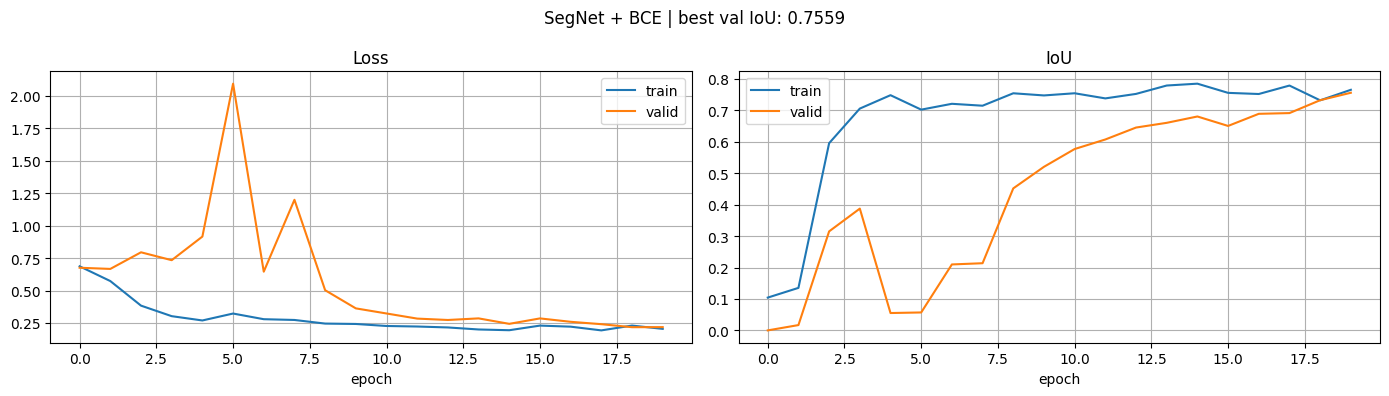

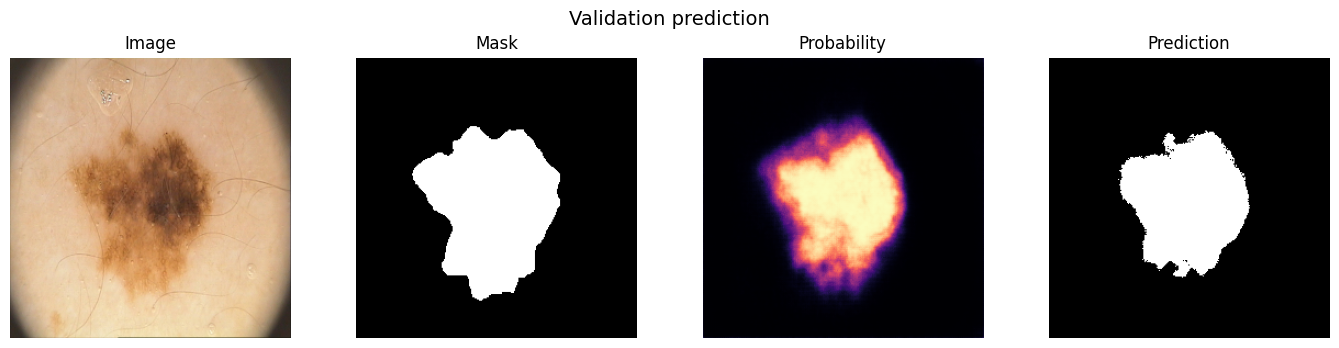

Epoch 020/020 | train loss 0.2048, train IoU 0.7653 | valid loss 0.2181, valid IoU 0.7559


In [87]:
EPOCHS = 20
LR = 1e-3

segnet_model = SegNet().to(device)
segnet_optimizer = optim.Adam(segnet_model.parameters(), lr=LR)
segnet_history = train(
    segnet_model,
    criterion=nn.BCEWithLogitsLoss(),
    optimizer=segnet_optimizer,
    epochs=EPOCHS,
    checkpoint_path='segnet_bce_best.pt',
    title='SegNet + BCE',
)


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [88]:
@torch.no_grad()
def test(model,
         dataloader=test_dataloader,
         criterion=None,
         checkpoint_path=None,
         device=device,
         title='Test prediction'):
    if criterion is None:
        criterion = nn.BCEWithLogitsLoss()
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        state = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state)

    metrics = evaluate(model, dataloader, criterion, device=device)
    print(f'Test loss: {metrics["loss"]:.4f}')
    print(f'Test IoU:  {metrics["iou"]:.4f}')
    show_predictions(model, next(iter(dataloader)), max_items=1, device=device, title=title)
    return metrics


Test loss: 0.2347
Test IoU:  0.7315


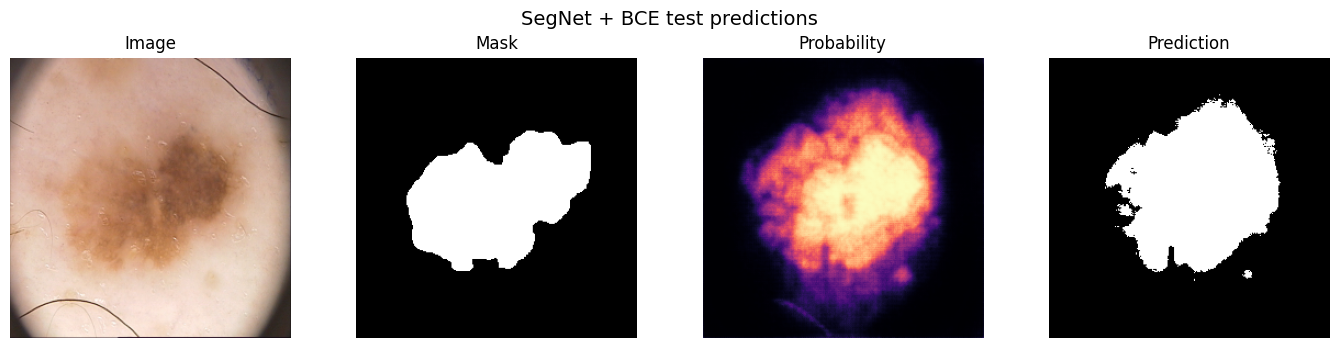

In [89]:
segnet_test_metrics = test(
    segnet_model,
    criterion=nn.BCEWithLogitsLoss(),
    checkpoint_path='segnet_bce_best.pt',
    title='SegNet + BCE test predictions',
)


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [90]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    """
    Это именно метрика, не лосс.
    """
    labels = labels.to(dtype=logits.dtype)
    preds = (torch.sigmoid(logits) > threshold).to(dtype=logits.dtype)

    tp = (preds * labels).sum()
    fp = (preds * (1 - labels)).sum()
    fn = ((1 - preds) * labels).sum()
    eps = torch.finfo(logits.dtype).eps
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return score


Проверим на корректность функцию dice_score:

In [91]:
from torchmetrics.classification import BinaryF1Score

# Для бинарной сегментации Dice совпадает с F1-score по пикселям.
dice = BinaryF1Score().to(device)
torch_dice_score = dice(
    (dummpy_sample['logits'].sigmoid() > 0.5).to(int),
    dummpy_sample['labels'].to(int),
)
torch_dice_score


tensor(0.6667, device='cuda:0')

In [92]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(device)\n\n"

In [93]:
assert torch.isclose(
    torch_dice_score.to(device),
    dice_score(dummpy_sample['logits'], dummpy_sample['labels']),
    atol=1e-6,
)


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [94]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    """
    Это лосс.
    """
    labels = labels.to(dtype=logits.dtype)
    probs = torch.sigmoid(logits)
    dims = tuple(range(0, logits.ndim))

    intersection = (probs * labels).sum(dim=dims)
    cardinality = probs.sum(dim=dims) + labels.sum(dim=dims)
    eps = 1e-7
    dice = (2.0 * intersection) / cardinality.clamp_min(eps)
    loss = 1.0 - dice

    return loss


Проверка на корректность:

In [95]:
try:
    import segmentation_models_pytorch
except ModuleNotFoundError:
    get_ipython().system('pip -q install segmentation-models-pytorch')


In [96]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [97]:
assert torch.isclose(
    dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)),
    dice_loss(dummpy_sample['logits'], dummpy_sample['labels'].to(int)),
    atol=1e-6,
)


### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [98]:
def focal_loss(y_real, y_pred, eps=1e-8, gamma=2):
    y_real = y_real.to(dtype=y_pred.dtype)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction='none')
    prob = torch.sigmoid(y_pred).clamp(min=eps, max=1 - eps)
    p_t = prob * y_real + (1 - prob) * (1 - y_real)
    loss = ((1 - p_t) ** gamma) * bce

    return loss.sum()


def focal_loss_mean(logits, labels, gamma=2):
    return focal_loss(labels, logits, gamma=gamma) / labels.numel()


Проверка корректности функции:

In [99]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [100]:
assert torch.allclose(
    sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum'),
    focal_loss(dummpy_sample['labels'], dummpy_sample['logits']),
    atol=1e-6,
)


## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [101]:
def _probs_and_labels(logits, labels):
    labels = labels.to(dtype=logits.dtype)
    probs = torch.sigmoid(logits)
    return probs, labels


def soft_iou_loss(logits, labels, eps=1e-7):
    probs, labels = _probs_and_labels(logits, labels)
    intersection = (probs * labels).sum()
    union = probs.sum() + labels.sum() - intersection
    return 1 - (intersection + eps) / (union + eps)


def tversky_loss(logits, labels, alpha=0.3, beta=0.7, eps=1e-7):
    probs, labels = _probs_and_labels(logits, labels)
    tp = (probs * labels).sum()
    fp = (probs * (1 - labels)).sum()
    fn = ((1 - probs) * labels).sum()
    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return 1 - tversky


def focal_tversky_loss(logits, labels, alpha=0.3, beta=0.7, gamma=4 / 3):
    return tversky_loss(logits, labels, alpha=alpha, beta=beta).pow(gamma)


def log_cosh_dice_loss(logits, labels):
    x = dice_loss(logits, labels)
    return torch.log((torch.exp(x) + torch.exp(-x)) / 2.0)


def ssim_loss(logits, labels, window_size=11, c1=0.01 ** 2, c2=0.03 ** 2):
    probs, labels = _probs_and_labels(logits, labels)
    padding = window_size // 2

    mu_x = F.avg_pool2d(probs, window_size, stride=1, padding=padding)
    mu_y = F.avg_pool2d(labels, window_size, stride=1, padding=padding)
    sigma_x = F.avg_pool2d(probs * probs, window_size, stride=1, padding=padding) - mu_x.pow(2)
    sigma_y = F.avg_pool2d(labels * labels, window_size, stride=1, padding=padding) - mu_y.pow(2)
    sigma_xy = F.avg_pool2d(probs * labels, window_size, stride=1, padding=padding) - mu_x * mu_y

    ssim = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / ((mu_x.pow(2) + mu_y.pow(2) + c1) * (sigma_x + sigma_y + c2))
    return torch.clamp((1 - ssim.mean()) / 2, min=0, max=1)


bonus_loss_fns = {
    'Soft IoU': soft_iou_loss,
    'Tversky': tversky_loss,
    'Focal Tversky': focal_tversky_loss,
    'Log-Cosh Dice': log_cosh_dice_loss,
    'SSIM': ssim_loss,
}

loss_values = {
    'BCE': nn.BCEWithLogitsLoss()(dummpy_sample['logits'], dummpy_sample['labels']).item(),
    'Dice': dice_loss(dummpy_sample['logits'], dummpy_sample['labels']).item(),
    'Focal': focal_loss_mean(dummpy_sample['logits'], dummpy_sample['labels']).item(),
}
for name, loss_fn in bonus_loss_fns.items():
    loss_values[name] = loss_fn(dummpy_sample['logits'], dummpy_sample['labels']).item()

pd.DataFrame(loss_values.items(), columns=['loss', 'value']).sort_values('value').reset_index(drop=True)


,loss,value
0,Log-Cosh Dice,0.157245
1,Focal,0.226008
2,SSIM,0.227699
3,BCE,0.373395
4,Focal Tversky,0.504533
5,Dice,0.575600
6,Tversky,0.598642
7,Soft IoU,0.730642


In [102]:
# Проверка корректности bonus loss-функций.
from segmentation_models_pytorch.losses import JaccardLoss, TverskyLoss

logits = dummpy_sample['logits']
labels = dummpy_sample['labels'].float()

# Soft IoU == JaccardLoss для binary segmentation.
jaccard_loss_torch = JaccardLoss(mode='binary', from_logits=True, smooth=0.0, eps=1e-7)
assert torch.allclose(
    soft_iou_loss(logits, labels),
    jaccard_loss_torch(logits, labels),
    atol=1e-6,
)

# Tversky и Focal Tversky сверяем с реализацией из segmentation_models_pytorch.
tversky_loss_torch = TverskyLoss(mode='binary', from_logits=True, alpha=0.3, beta=0.7, gamma=1.0, smooth=0.0, eps=1e-7)
assert torch.allclose(
    tversky_loss(logits, labels),
    tversky_loss_torch(logits, labels),
    atol=1e-6,
)

focal_tversky_loss_torch = TverskyLoss(mode='binary', from_logits=True, alpha=0.3, beta=0.7, gamma=4 / 3, smooth=0.0, eps=1e-7)
assert torch.allclose(
    focal_tversky_loss(logits, labels),
    focal_tversky_loss_torch(logits, labels),
    atol=1e-6,
)

# Log-Cosh Dice строится поверх уже проверенного DiceLoss.
expected_log_cosh_dice = torch.log(torch.cosh(dice_loss_torch(logits, labels)))
assert torch.allclose(
    log_cosh_dice_loss(logits, labels),
    expected_log_cosh_dice,
    atol=1e-6,
)

# SSIM сверяем с независимой реализацией через conv2d с равномерным окном.
def ssim_loss_reference(logits, labels, window_size=11, c1=0.01 ** 2, c2=0.03 ** 2):
    probs, labels = _probs_and_labels(logits, labels)
    padding = window_size // 2
    channels = probs.shape[1]
    kernel = torch.ones(channels, 1, window_size, window_size, device=probs.device, dtype=probs.dtype)
    kernel = kernel / (window_size ** 2)

    mu_x = F.conv2d(probs, kernel, padding=padding, groups=channels)
    mu_y = F.conv2d(labels, kernel, padding=padding, groups=channels)
    sigma_x = F.conv2d(probs * probs, kernel, padding=padding, groups=channels) - mu_x.pow(2)
    sigma_y = F.conv2d(labels * labels, kernel, padding=padding, groups=channels) - mu_y.pow(2)
    sigma_xy = F.conv2d(probs * labels, kernel, padding=padding, groups=channels) - mu_x * mu_y

    ssim = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / ((mu_x.pow(2) + mu_y.pow(2) + c1) * (sigma_x + sigma_y + c2))
    return torch.clamp((1 - ssim.mean()) / 2, min=0, max=1)

assert torch.allclose(
    ssim_loss(logits, labels),
    ssim_loss_reference(logits, labels),
    atol=1e-6,
)

# У каждого нового лосса должен проходить backprop без NaN/Inf.
for loss_name, loss_fn in bonus_loss_fns.items():
    checked_logits = logits.detach().clone().requires_grad_(True)
    loss_value = loss_fn(checked_logits, labels)
    assert loss_value.ndim == 0, f'{loss_name}: loss must be scalar'
    assert torch.isfinite(loss_value), f'{loss_name}: loss is not finite'
    loss_value.backward()
    assert checked_logits.grad is not None, f'{loss_name}: no gradient'
    assert torch.isfinite(checked_logits.grad).all(), f'{loss_name}: gradient is not finite'

print('All bonus loss checks passed')


All bonus loss checks passed


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [103]:
COMPARISON_EPOCHS = EPOCHS

segnet_histories = {'SegNet BCE': segnet_history}
segnet_models = {'SegNet BCE': segnet_model}


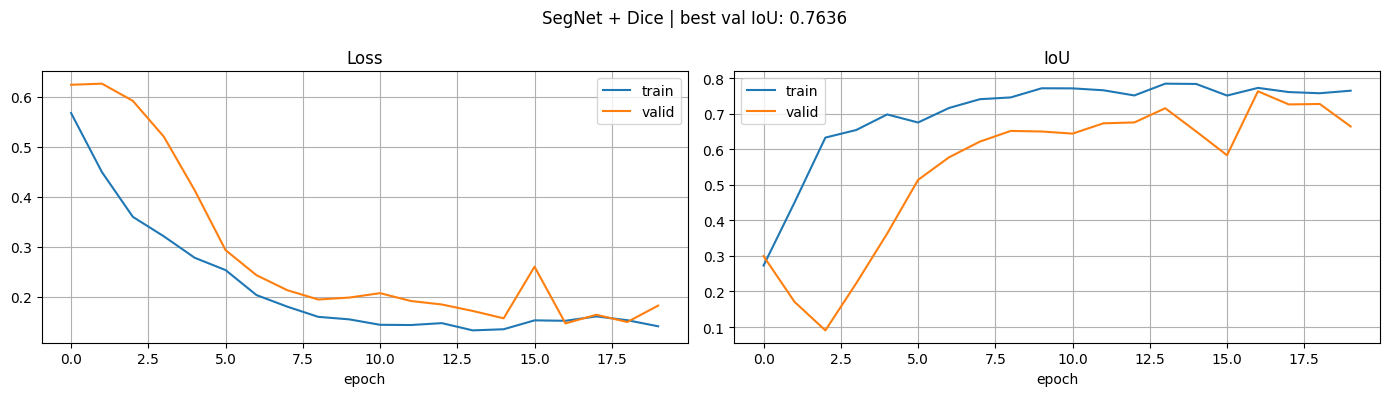

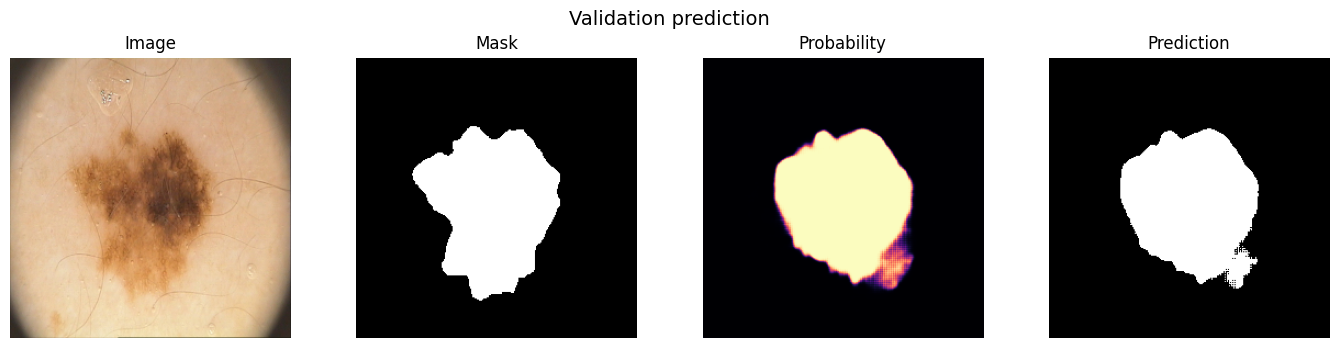

Epoch 020/020 | train loss 0.1406, train IoU 0.7653 | valid loss 0.1820, valid IoU 0.6646


In [104]:
segnet_dice_model = SegNet().to(device)
segnet_dice_optimizer = optim.Adam(segnet_dice_model.parameters(), lr=LR)
segnet_dice_history = train(
    segnet_dice_model,
    criterion=dice_loss,
    optimizer=segnet_dice_optimizer,
    epochs=COMPARISON_EPOCHS,
    checkpoint_path='segnet_dice_best.pt',
    title='SegNet + Dice',
)
segnet_histories['SegNet Dice'] = segnet_dice_history
segnet_models['SegNet Dice'] = segnet_dice_model


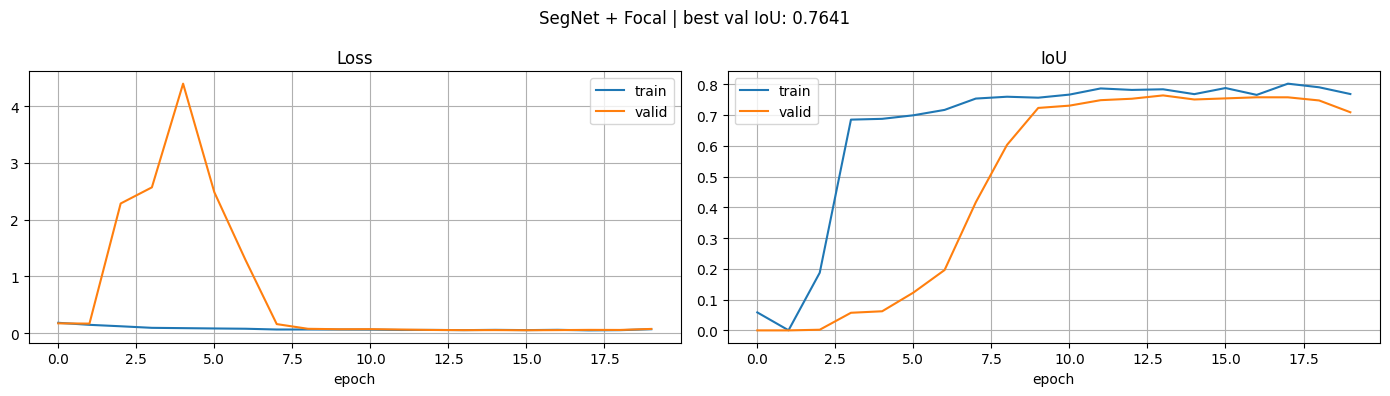

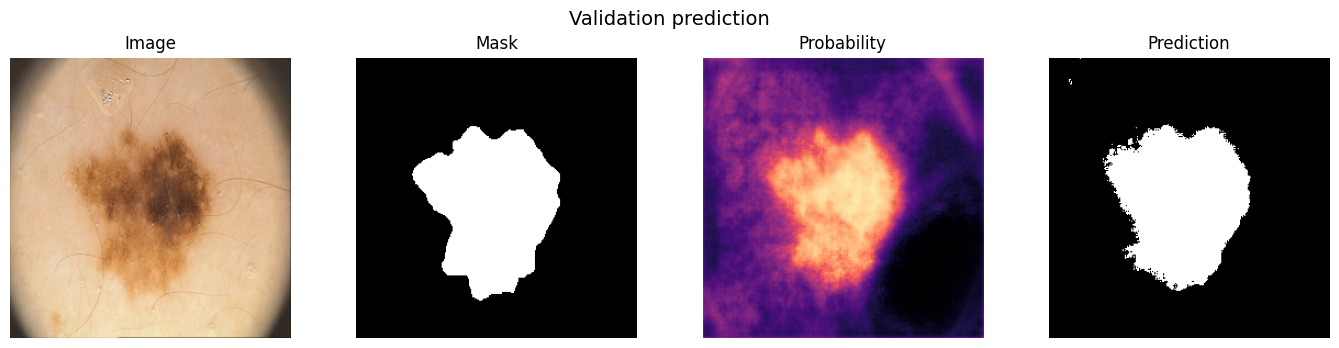

Epoch 020/020 | train loss 0.0684, train IoU 0.7686 | valid loss 0.0737, valid IoU 0.7093


In [105]:
segnet_focal_model = SegNet().to(device)
segnet_focal_optimizer = optim.Adam(segnet_focal_model.parameters(), lr=LR)
segnet_focal_history = train(
    segnet_focal_model,
    criterion=focal_loss_mean,
    optimizer=segnet_focal_optimizer,
    epochs=COMPARISON_EPOCHS,
    checkpoint_path='segnet_focal_best.pt',
    title='SegNet + Focal',
)
segnet_histories['SegNet Focal'] = segnet_focal_history
segnet_models['SegNet Focal'] = segnet_focal_model


In [106]:
summarize_histories(segnet_histories)


,run,best_val_iou,final_val_iou,best_val_loss,final_val_loss,seconds
0,SegNet Focal,0.764109,0.709310,0.050500,0.073749,136.108374
1,SegNet Dice,0.763577,0.664608,0.146416,0.181960,135.150198
2,SegNet BCE,0.755908,0.755908,0.217666,0.218124,138.333258


# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

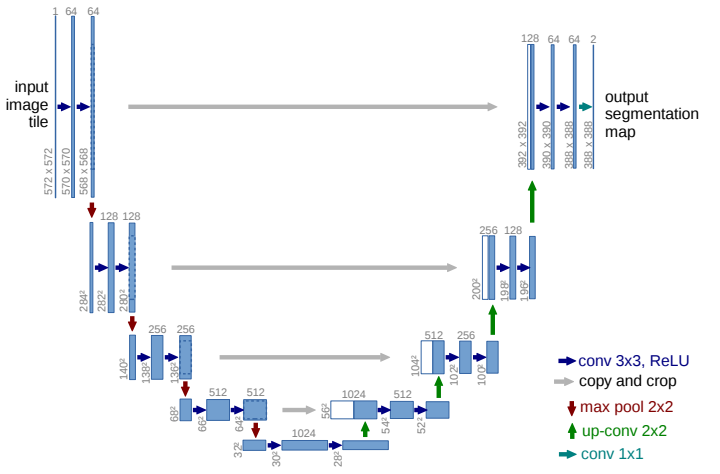

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [107]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [108]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        if diff_y != 0 or diff_x != 0:
            x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3, base_channels=32):
        super().__init__()

        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DownBlock(base_channels * 8, base_channels * 16)

        self.up1 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels, base_channels)
        self.outc = nn.Conv2d(base_channels, n_class, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        output = self.outc(x)

        return output


In [109]:
unet_model = UNet().to(device)


## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



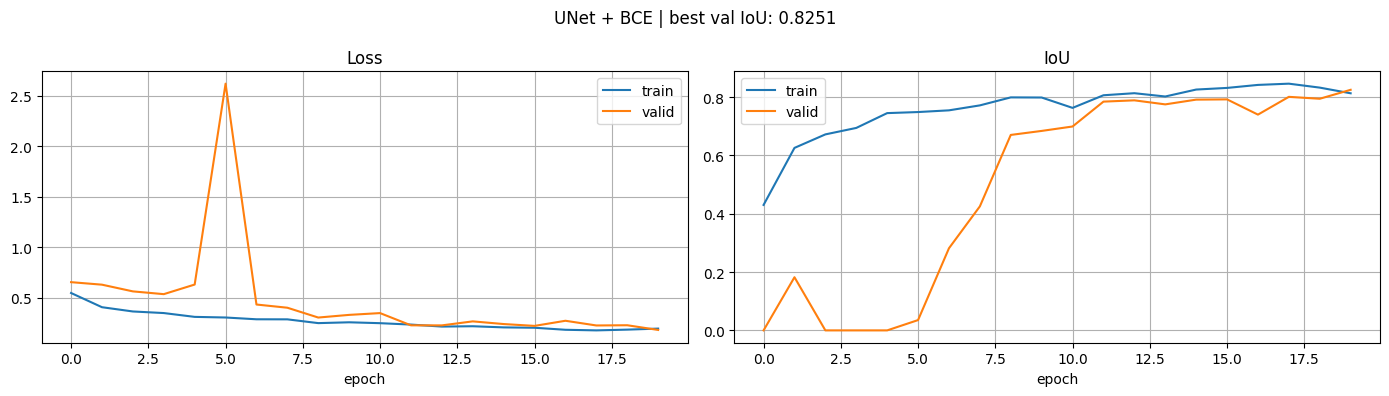

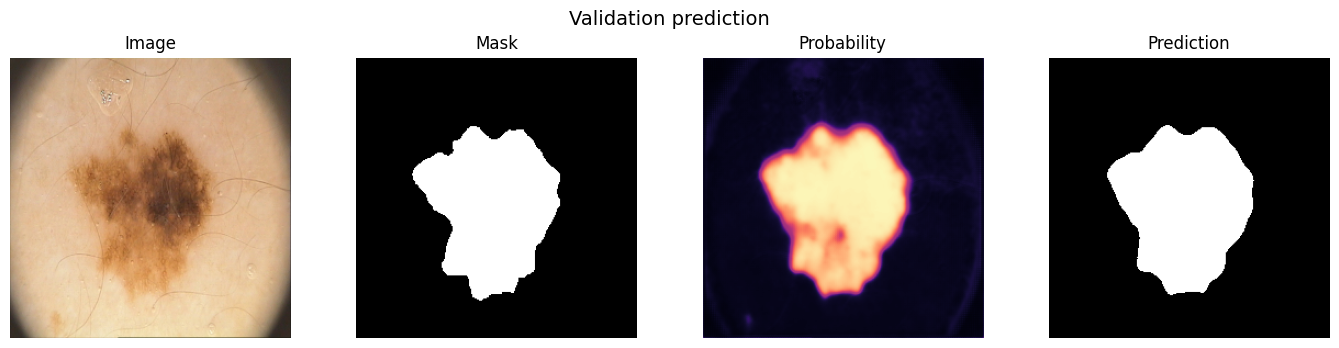

Epoch 020/020 | train loss 0.1946, train IoU 0.8131 | valid loss 0.1813, valid IoU 0.8251


In [110]:
unet_histories = {}
unet_models = {}

unet_bce_model = UNet().to(device)
unet_bce_optimizer = optim.Adam(unet_bce_model.parameters(), lr=LR)
unet_bce_history = train(
    unet_bce_model,
    criterion=nn.BCEWithLogitsLoss(),
    optimizer=unet_bce_optimizer,
    epochs=COMPARISON_EPOCHS,
    checkpoint_path='unet_bce_best.pt',
    title='UNet + BCE',
)
unet_histories['UNet BCE'] = unet_bce_history
unet_models['UNet BCE'] = unet_bce_model


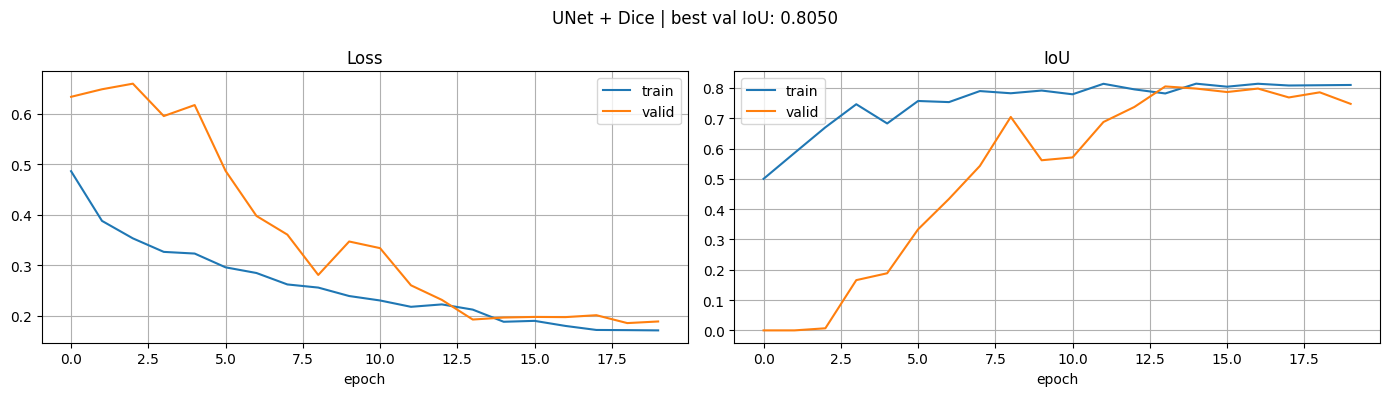

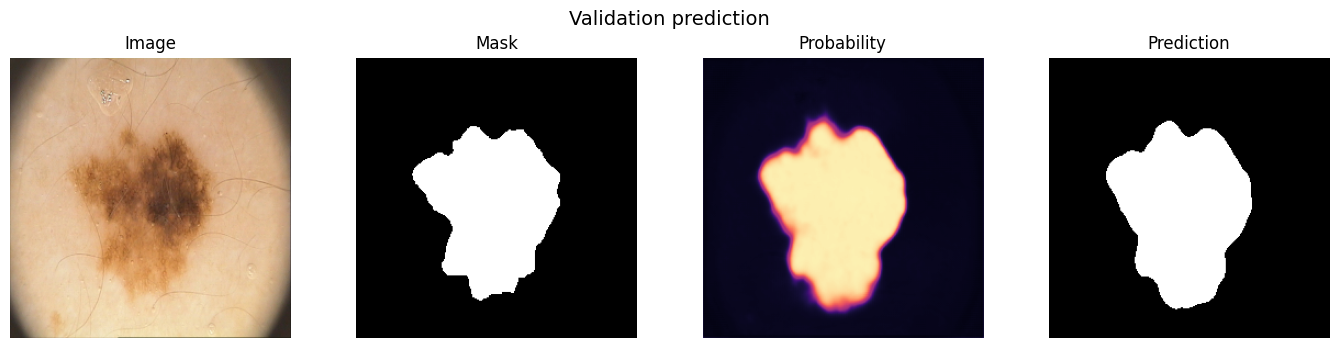

Epoch 020/020 | train loss 0.1713, train IoU 0.8098 | valid loss 0.1889, valid IoU 0.7474


In [111]:
unet_dice_model = UNet().to(device)
unet_dice_optimizer = optim.Adam(unet_dice_model.parameters(), lr=LR)
unet_dice_history = train(
    unet_dice_model,
    criterion=dice_loss,
    optimizer=unet_dice_optimizer,
    epochs=COMPARISON_EPOCHS,
    checkpoint_path='unet_dice_best.pt',
    title='UNet + Dice',
)
unet_histories['UNet Dice'] = unet_dice_history
unet_models['UNet Dice'] = unet_dice_model


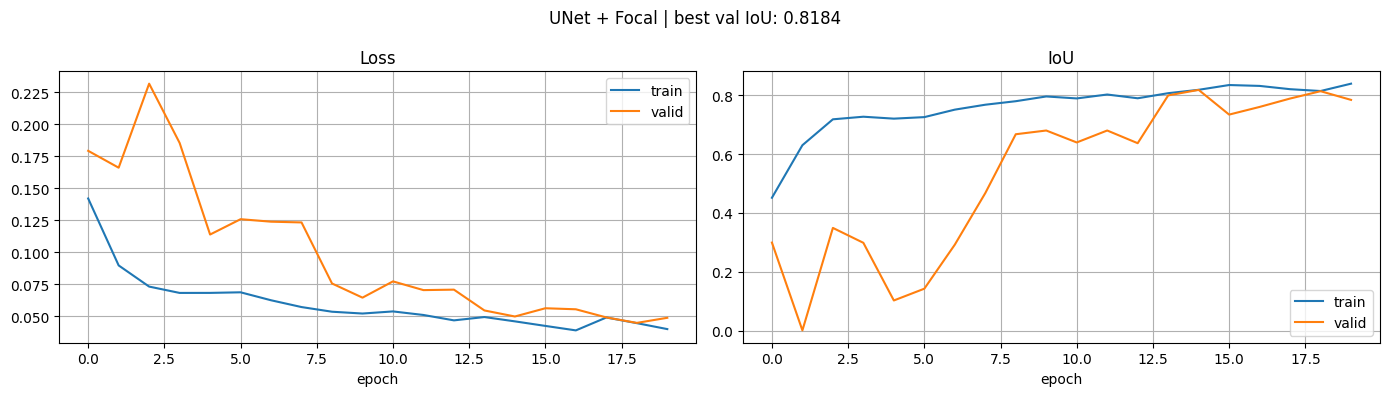

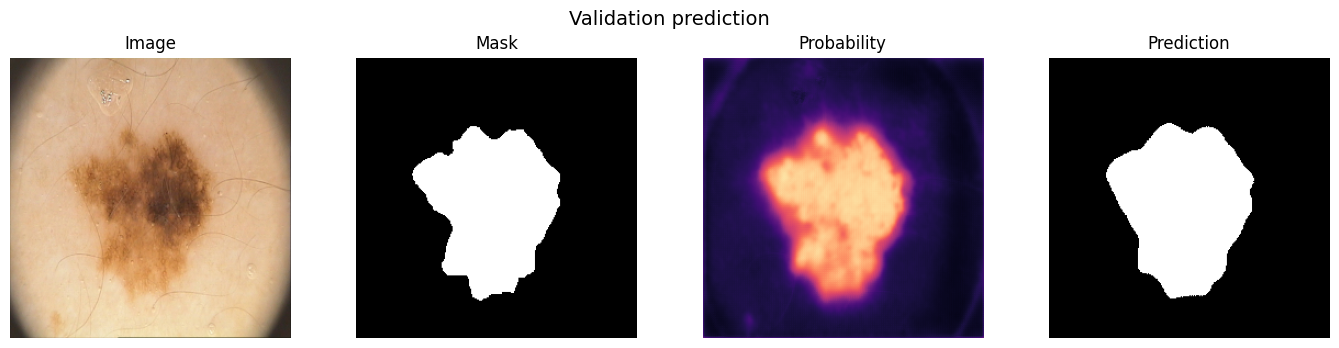

Epoch 020/020 | train loss 0.0400, train IoU 0.8395 | valid loss 0.0489, valid IoU 0.7844


In [112]:
unet_focal_model = UNet().to(device)
unet_focal_optimizer = optim.Adam(unet_focal_model.parameters(), lr=LR)
unet_focal_history = train(
    unet_focal_model,
    criterion=focal_loss_mean,
    optimizer=unet_focal_optimizer,
    epochs=COMPARISON_EPOCHS,
    checkpoint_path='unet_focal_best.pt',
    title='UNet + Focal',
)
unet_histories['UNet Focal'] = unet_focal_history
unet_models['UNet Focal'] = unet_focal_model


In [113]:
all_histories = {**segnet_histories, **unet_histories}
summary = summarize_histories(all_histories)
summary


,run,best_val_iou,final_val_iou,best_val_loss,final_val_loss,seconds
0,UNet BCE,0.825061,0.825061,0.181332,0.181332,67.295196
1,UNet Focal,0.818359,0.784375,0.044866,0.048855,68.486589
2,UNet Dice,0.805010,0.747446,0.185687,0.188865,68.266062
3,SegNet Focal,0.764109,0.709310,0.050500,0.073749,136.108374
4,SegNet Dice,0.763577,0.664608,0.146416,0.181960,135.150198
5,SegNet BCE,0.755908,0.755908,0.217666,0.218124,138.333258


Best validation run: UNet BCE


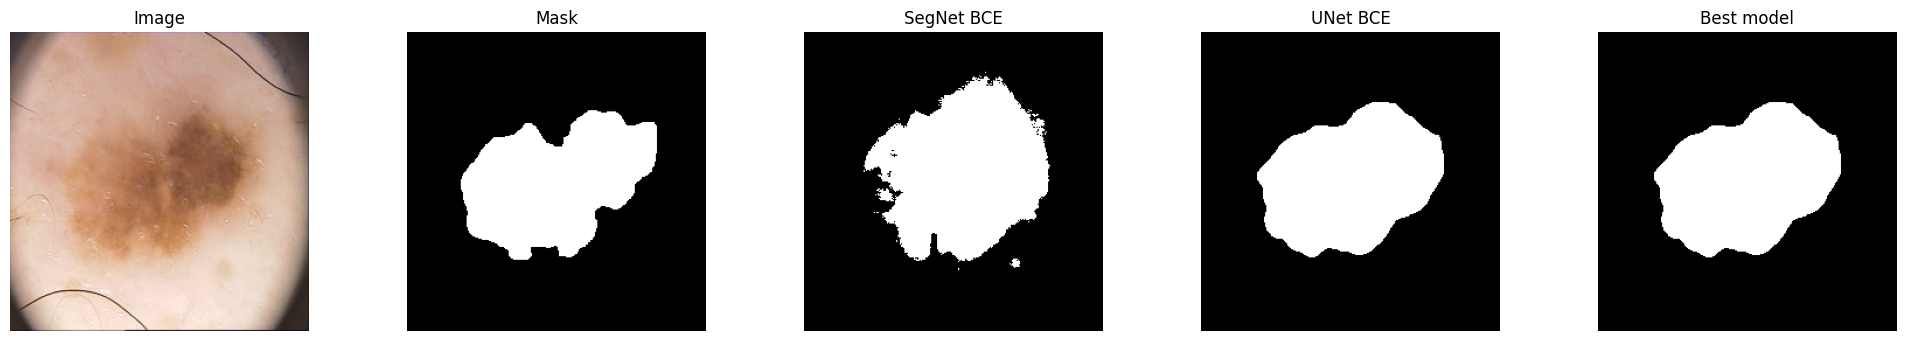

In [114]:
best_run = summary.iloc[0]['run']
best_model = {**segnet_models, **unet_models}[best_run]
print(f'Best validation run: {best_run}')

comparison_models = {
    'SegNet BCE': segnet_models['SegNet BCE'],
    'UNet BCE': unet_models['UNet BCE'],
    'Best model': best_model,
}

compare_models(comparison_models, dataloader=test_dataloader, max_items=1, device=device)


**Вывод:**

По метрике IoU лучшее значение показал UNet BCE. Минимальное значение loss получилось у UNet Focal, но лоссы разных типов имеют разные шкалы, поэтому напрямую сравнивать их между собой менее корректно, чем сравнивать IoU.

Лучшего значения IoU быстрее всего достигают модели SegNet Focal и Unet Dice (13 эпох).

Из сравнения Unet и SegNet видно, что Unet обгоняет SegNet как минимум на 0.05 IoU, что обусловлено спецификой задачи (медицинские снимки).